In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from tqdm import tqdm
import torch
import pickle
from collections import Counter

In [3]:
RANDOM_STATE = 42
TEST_SIZE = 0.2

## Load Data

In [4]:
with open("all_segments.pkl", "rb") as f:
    segments = pickle.load(f)

In [5]:
pulses_df = pd.read_csv("pulses.csv")

In [6]:
drop_cols = ["row_id", "start_idx",	"min_idx",	"end_idx"]

In [7]:
X = pulses_df.drop(columns=drop_cols, errors="ignore")
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Clustering con K-Means

KMeans codo: 100%|██████████| 13/13 [00:22<00:00,  1.71s/it]


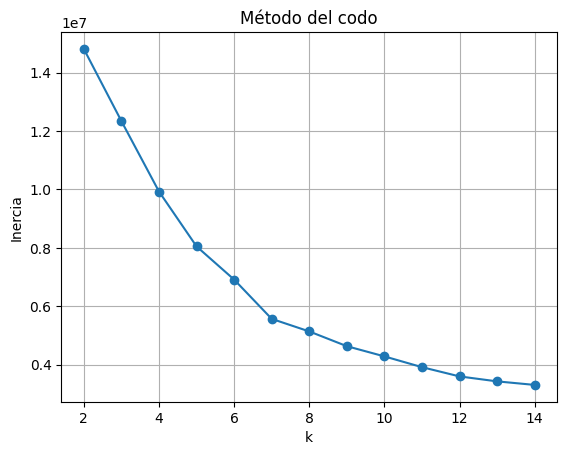

In [8]:
inertias = []
K_range = range(2, 15)
for k in tqdm(K_range, desc="KMeans codo"):
    km = KMeans(n_clusters=k, n_init="auto", random_state=42)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

plt.plot(K_range, inertias, marker="o")
plt.title("Método del codo")
plt.grid()
plt.xlabel("k"); plt.ylabel("Inercia"); plt.show()

In [9]:
best_k = 8
kmeans = KMeans(n_clusters=best_k, n_init="auto", random_state=42)
labels = kmeans.fit_predict(X_scaled)
#pulses_df["cluster"] = labels

### PCA para visualización 2D/3D

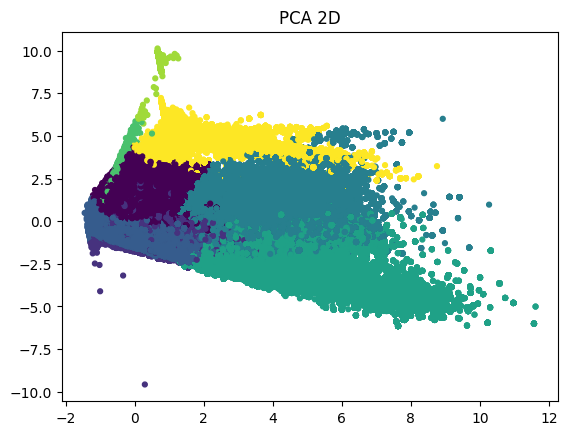

In [10]:
pca2 = PCA(n_components=2)
Xp2 = pca2.fit_transform(X_scaled)
plt.scatter(Xp2[:,0], Xp2[:,1], c=labels, s=12, cmap="viridis")
plt.title("PCA 2D"); plt.show()

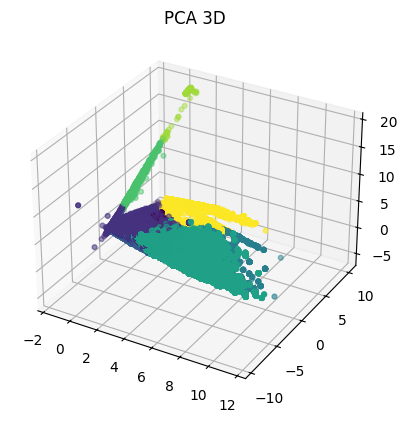

In [11]:
from mpl_toolkits.mplot3d import Axes3D
pca3 = PCA(n_components=3)
Xp3 = pca3.fit_transform(X_scaled)
fig = plt.figure(); ax = fig.add_subplot(111, projection="3d")
ax.scatter(Xp3[:,0], Xp3[:,1], Xp3[:,2], c=labels, s=12, cmap="viridis")
plt.title("PCA 3D"); plt.show()

In [13]:
import numpy as np
import matplotlib.pyplot as plt
import math

def _cut_around_min(seg: np.ndarray, n_before: int, n_after: int):
    if len(seg) == 0:
        return seg
    kmin = int(np.argmin(seg))
    a = max(0, kmin - n_before)
    b = min(len(seg), kmin + n_after + 1)
    return seg[a:b]

def _align_and_normalize(seg: np.ndarray, align='min', normalize=True, scale=None, eps=1e-9):
    s = seg.astype(float).copy()
    if normalize:
        s = s - np.median(s)
    if scale == 'maxabs':
        m = np.max(np.abs(s))
        if m > eps:
            s = s / m
    elif scale == 'robust':
        p5, p95 = np.percentile(s, [5, 95])
        rng = p95 - p5
        if rng > eps:
            s = (s - p5) / rng
    return s

def _resample_to_fixed(seg: np.ndarray, out_len: int):
    L = len(seg)
    if L == 0:
        return np.zeros(out_len)
    if L == out_len:
        return seg
    x_old = np.linspace(0, 1, L)
    x_new = np.linspace(0, 1, out_len)
    return np.interp(x_new, x_old, seg)

def compare_pulse_segments_overlay(
    segments,
    labels,
    mode='same',
    classes=None,
    n=12,
    n_before=20,
    n_after=40,
    align='min',
    normalize=True,
    resample_len=120,
    show_median=True,
    title=None,
    rng_seed=42,
    ax=None,                 
    alpha=0.45,              
    median_kwargs=None,      
    plot_kwargs=None,        
    show_legend=True,        
    show_now=None,
    scale=None,                 # None | "maxabs" | "robust"
    y_percentile=None
):
    """
    Dibuja SÓLO los pulsos recortados alrededor del mínimo.
    Si 'ax' es None, crea su propia figura. Si 'ax' es un eje, dibuja ahí.
    Retorna: dict con {'ax', 'waves', 'median'} para reutilizar resultados.
    """
    labs = np.asarray(labels)
    if mode == 'same':
        if not classes or len(classes) != 1:
            raise ValueError("Para mode='same' usa classes=[clase].")
        c = classes[0]
        idx = np.where(labs == c)[0]
        title = title or f"Pulsos superpuestos (misma clase {c})"
    else:
        if not classes or len(classes) < 2:
            uniq = np.unique(labs)
            classes = list(uniq[:2])
        idx = np.concatenate([np.where(labs == c)[0] for c in classes])
        title = title or f"Pulsos superpuestos (clases {classes})"

    if len(idx) == 0:
        print("No hay pulsos para los criterios indicados.")
        return {'ax': ax, 'waves': [], 'median': None}

    rng = np.random.default_rng(rng_seed)
    idx = rng.choice(idx, size=min(n, len(idx)), replace=False)

    created_fig = False
    if ax is None:
        fig, ax = plt.subplots(figsize=(8,4))
        created_fig = True

    waves = []
    _plot_kwargs = dict()
    if plot_kwargs:
        _plot_kwargs.update(plot_kwargs)

    for k in idx:
        seg = np.asarray(segments[k]["values"]).astype(float)
        seg = _cut_around_min(seg, n_before=n_before, n_after=n_after)
        seg = _align_and_normalize(seg, align=align, normalize=normalize, scale=scale)
        seg = _resample_to_fixed(seg, out_len=resample_len)
        waves.append(seg)
        ax.plot(seg, alpha=alpha, **_plot_kwargs)

    med = None
    if show_median and len(waves) > 0:
        med = np.median(np.vstack(waves), axis=0)
        mk = dict(lw=2.5, label="Mediana", zorder=10)
        if median_kwargs:
            mk.update(median_kwargs)
        ax.plot(med, **mk)

    # Ajuste de Y por percentiles (por subplot)
    if y_percentile is not None and len(waves) > 0:
        lo, hi = np.percentile(np.hstack(waves), y_percentile)
        if lo == hi:  # evita colapso si todos son iguales
            lo -= 1.0
            hi += 1.0
        ax.set_ylim(lo, hi)

    ax.set_title(title)
    ax.set_xlabel("Muestras (re-muestreadas)")
    ax.set_ylabel("Amplitud normalizada" if normalize else "Amplitud")
    if show_median and show_legend:
        ax.legend()
    ax.grid(True)
    plt.tight_layout()

    # Decidir si llamar plt.show()
    if show_now is None:
        # Si nosotros creamos la figura, mostramos; si no, dejamos al caller.
        show_now = created_fig
    if show_now and created_fig:
        plt.show()

    return {'ax': ax, 'waves': waves, 'median': med}


def compare_pulse_subplots(
    segments, labels, classes_list,
    ncols=3, figsize=(12, 4), sharey=False, **kwargs
):
    import math
    n = len(classes_list)
    nrows = math.ceil(n / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=figsize, sharey=sharey)
    axes = np.atleast_1d(axes).ravel()

    for i, c in enumerate(classes_list):
        compare_pulse_segments_overlay(
            segments, labels,
            mode='same', classes=[c],
            ax=axes[i],
            show_now=False,
            show_legend=(i == 0),
            **kwargs
        )
    for j in range(i+1, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()
    return axes

In [ ]:
compare_pulse_segments_overlay(
    segments, labels,
    mode='same', classes=[1],
    n=15, n_before=20, n_after=40,
    align='min', normalize=True, resample_len=120, show_median=True
)

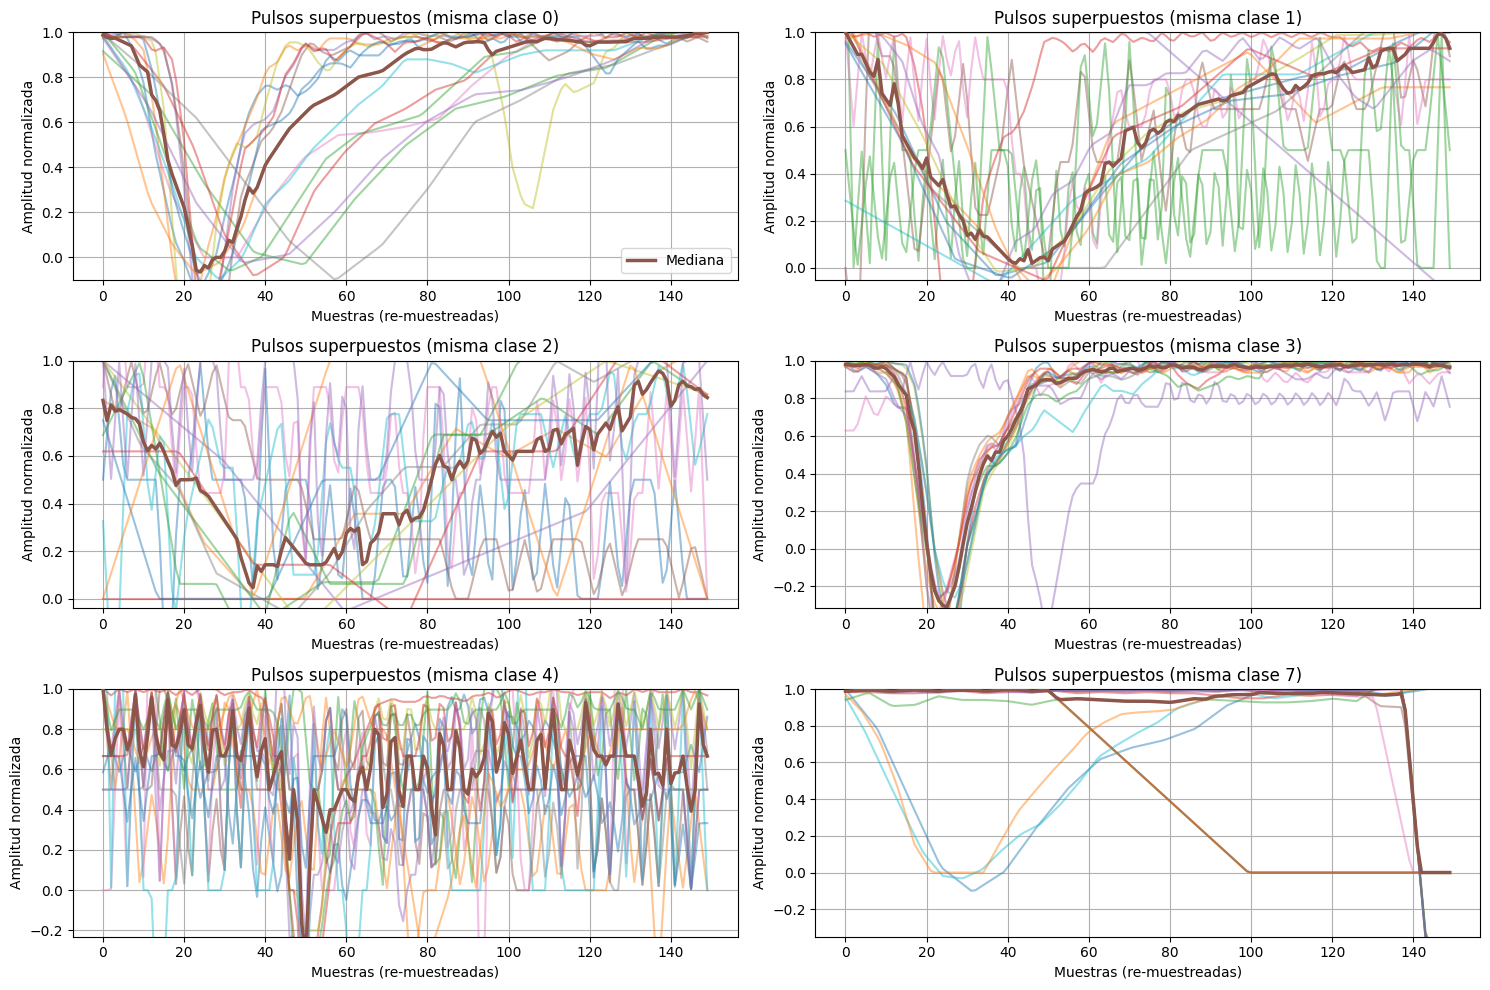

array([<Axes: title={'center': 'Pulsos superpuestos (misma clase 0)'}, xlabel='Muestras (re-muestreadas)', ylabel='Amplitud normalizada'>,
       <Axes: title={'center': 'Pulsos superpuestos (misma clase 1)'}, xlabel='Muestras (re-muestreadas)', ylabel='Amplitud normalizada'>,
       <Axes: title={'center': 'Pulsos superpuestos (misma clase 2)'}, xlabel='Muestras (re-muestreadas)', ylabel='Amplitud normalizada'>,
       <Axes: title={'center': 'Pulsos superpuestos (misma clase 3)'}, xlabel='Muestras (re-muestreadas)', ylabel='Amplitud normalizada'>,
       <Axes: title={'center': 'Pulsos superpuestos (misma clase 4)'}, xlabel='Muestras (re-muestreadas)', ylabel='Amplitud normalizada'>,
       <Axes: title={'center': 'Pulsos superpuestos (misma clase 7)'}, xlabel='Muestras (re-muestreadas)', ylabel='Amplitud normalizada'>],
      dtype=object)

In [15]:

compare_pulse_subplots(
    segments, labels,
    classes_list=[0,1,2,3,4,7],
    ncols=2, figsize=(15,10),
    n=15, n_before=25, n_after=50,
    resample_len=150, normalize=True,
    scale="robust", y_percentile=(2, 98)
)

In [17]:

element_counts = Counter(labels)
print(f"Counts of all elements : {element_counts}")

Counts of all elements : Counter({np.int32(2): 1252551, np.int32(0): 517775, np.int32(3): 226776, np.int32(1): 201172, np.int32(4): 103253, np.int32(7): 61185, np.int32(5): 2706, np.int32(6): 1035})


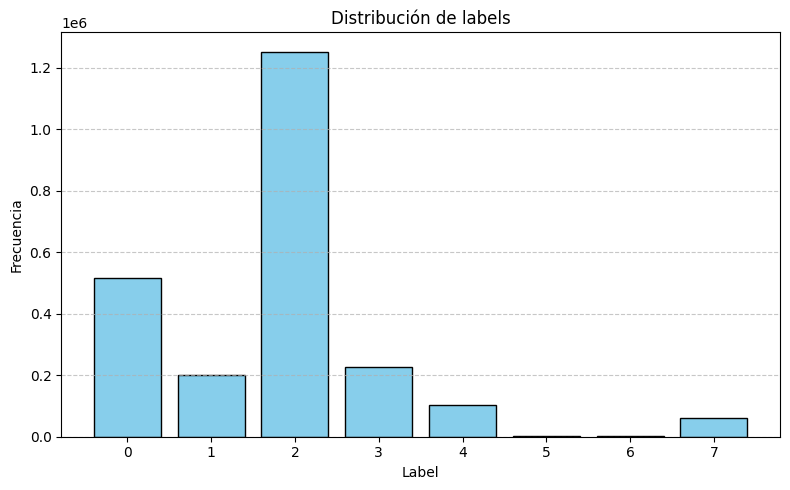

In [18]:
unique, counts = np.unique(labels, return_counts=True)

# Gráfico de barras
plt.figure(figsize=(8, 5))
plt.bar(unique, counts, color='skyblue', edgecolor='black')
plt.title("Distribución de labels")
plt.xlabel("Label")
plt.ylabel("Frecuencia")
plt.xticks(unique)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Modelos de  Clasificación

#### Dividir dataset

In [19]:
#Xtr, Xte, ytr, yte = train_test_split(X_scaled, labels, test_size=0.2, random_state=42, stratify=labels)

In [20]:
X.head()

,min_value,baseline_local,depth,width_samples,area_under_pulse,fwhm_samples,rise_time,recovery_time,snr_depth_over_mad
0,113.0,195.0,82.0,12,528.0,6,3,8,13.666667
1,147.0,195.0,48.0,46,375.0,5,10,35,48.000000
2,147.0,195.0,48.0,46,375.0,5,10,35,48.000000
3,157.0,195.0,38.0,153,396.0,5,76,76,38.000000
4,157.0,195.0,38.0,153,396.0,5,76,76,38.000000


In [21]:
feature_cols = list(X.columns)

In [22]:
X_trval, X_te, y_trval, y_te = train_test_split(
    X, labels, test_size=0.2, random_state=42, stratify=labels
)
# luego separamos val del resto
X_tr, X_val, y_tr, y_val = train_test_split(
    X_trval, y_trval, test_size=0.25, random_state=42, stratify=y_trval
)

In [23]:
# --- scaler (ajustar SOLO con train) ---
scaler = StandardScaler()
X_tr_s = scaler.fit_transform(X_tr)
X_val_s = scaler.transform(X_val)
X_te_s  = scaler.transform(X_te)

num_classes = len(np.unique(labels))

## Modelo de Arbol

In [24]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt

In [25]:
# Entrenamos el árbol (usamos train+val para que tenga más datos; o sólo train si prefieres)
X_train_for_tree = np.vstack([X_tr_s, X_val_s])
y_train_for_tree = np.concatenate([y_tr, y_val])

dt = DecisionTreeClassifier(
    criterion="gini",
    max_depth=4,        # ajusta según sobreajuste
    min_samples_leaf=10,
    random_state=42
)
dt.fit(X_train_for_tree, y_train_for_tree)

# Predicción en test
proba_tree = dt.predict_proba(X_te_s)
yhat_dt = proba_tree.argmax(axis=1)


In [26]:
# Importancias
importances = pd.Series(dt.feature_importances_, index=feature_cols).sort_values(ascending=False)
print("Top importances (árbol):")
print(importances.head(10))

Top importances (árbol):
depth                 0.491374
baseline_local        0.223302
recovery_time         0.173098
width_samples         0.102339
fwhm_samples          0.004768
rise_time             0.002091
min_value             0.001638
snr_depth_over_mad    0.001390
area_under_pulse      0.000000
dtype: float64


=== Métricas agregadas ===
Macro     -> P: 0.8416 | R: 0.8417 | F1: 0.8415
Weighted  -> P: 0.9762 | R: 0.9770 | F1: 0.9765

=== Classification report (por clase) ===
              precision    recall  f1-score   support

           0       0.96      0.99      0.98    103555
           1       0.97      0.95      0.96     40235
           2       1.00      0.99      0.99    250510
           3       0.97      0.93      0.95     45355
           4       0.85      0.89      0.87     20651
           5       0.00      0.00      0.00       541
           6       1.00      0.98      0.99       207
           7       0.99      0.99      0.99     12237

    accuracy                           0.98    473291
   macro avg       0.84      0.84      0.84    473291
weighted avg       0.98      0.98      0.98    473291



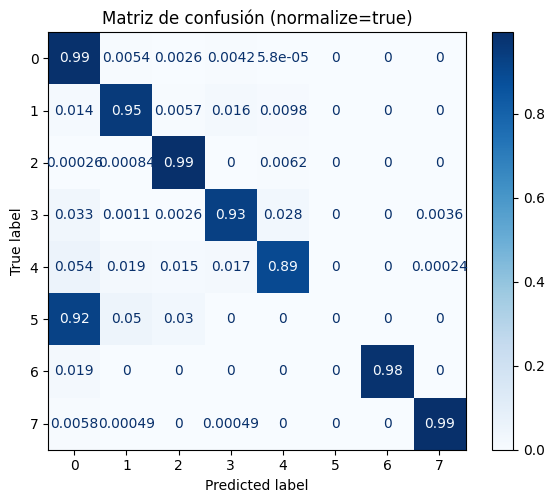


ROC-AUC multiclase:
  micro-average: 0.9976
  macro-average (ovr): 0.9765


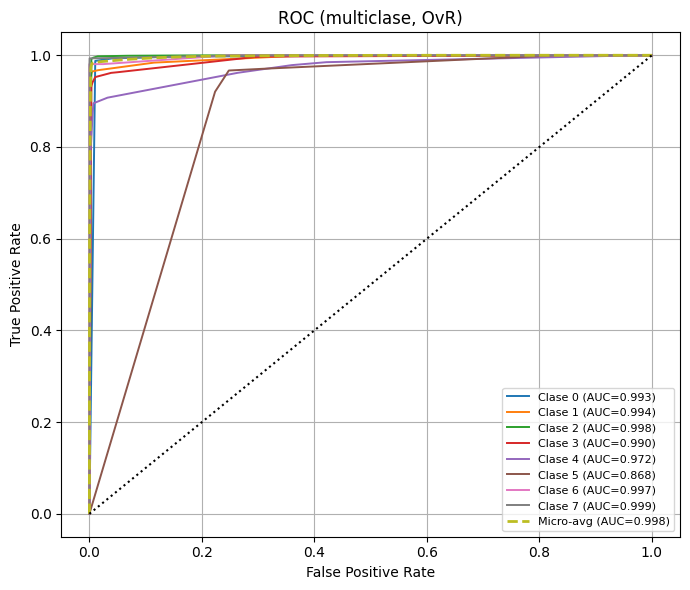


Average Precision multiclase:
  micro-average AP: 0.9866
  clase 0 AP: 0.9600
  clase 1 AP: 0.9602
  clase 2 AP: 0.9966
  clase 3 AP: 0.9368
  clase 4 AP: 0.8619
  clase 5 AP: 0.0046
  clase 6 AP: 0.9807
  clase 7 AP: 0.9929


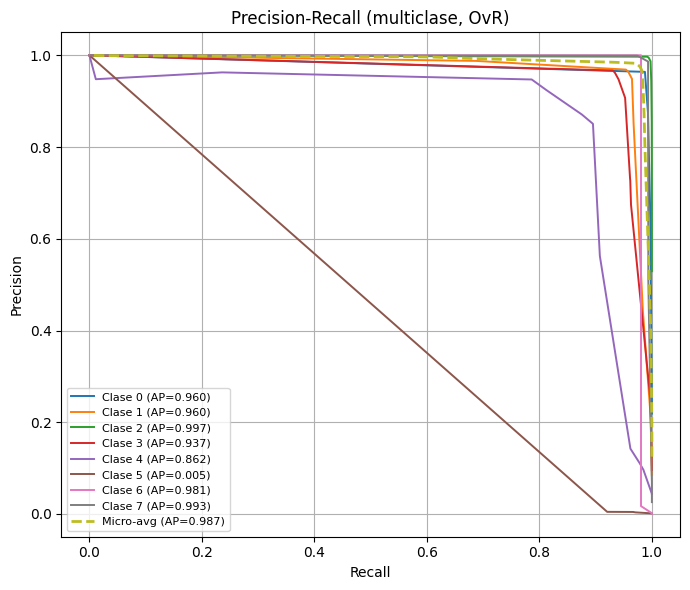

In [30]:
_ = eval_predictions(y_true=y_te, y_pred=proba_tree, plot_cm=True, plot_roc=True, plot_pr=True)

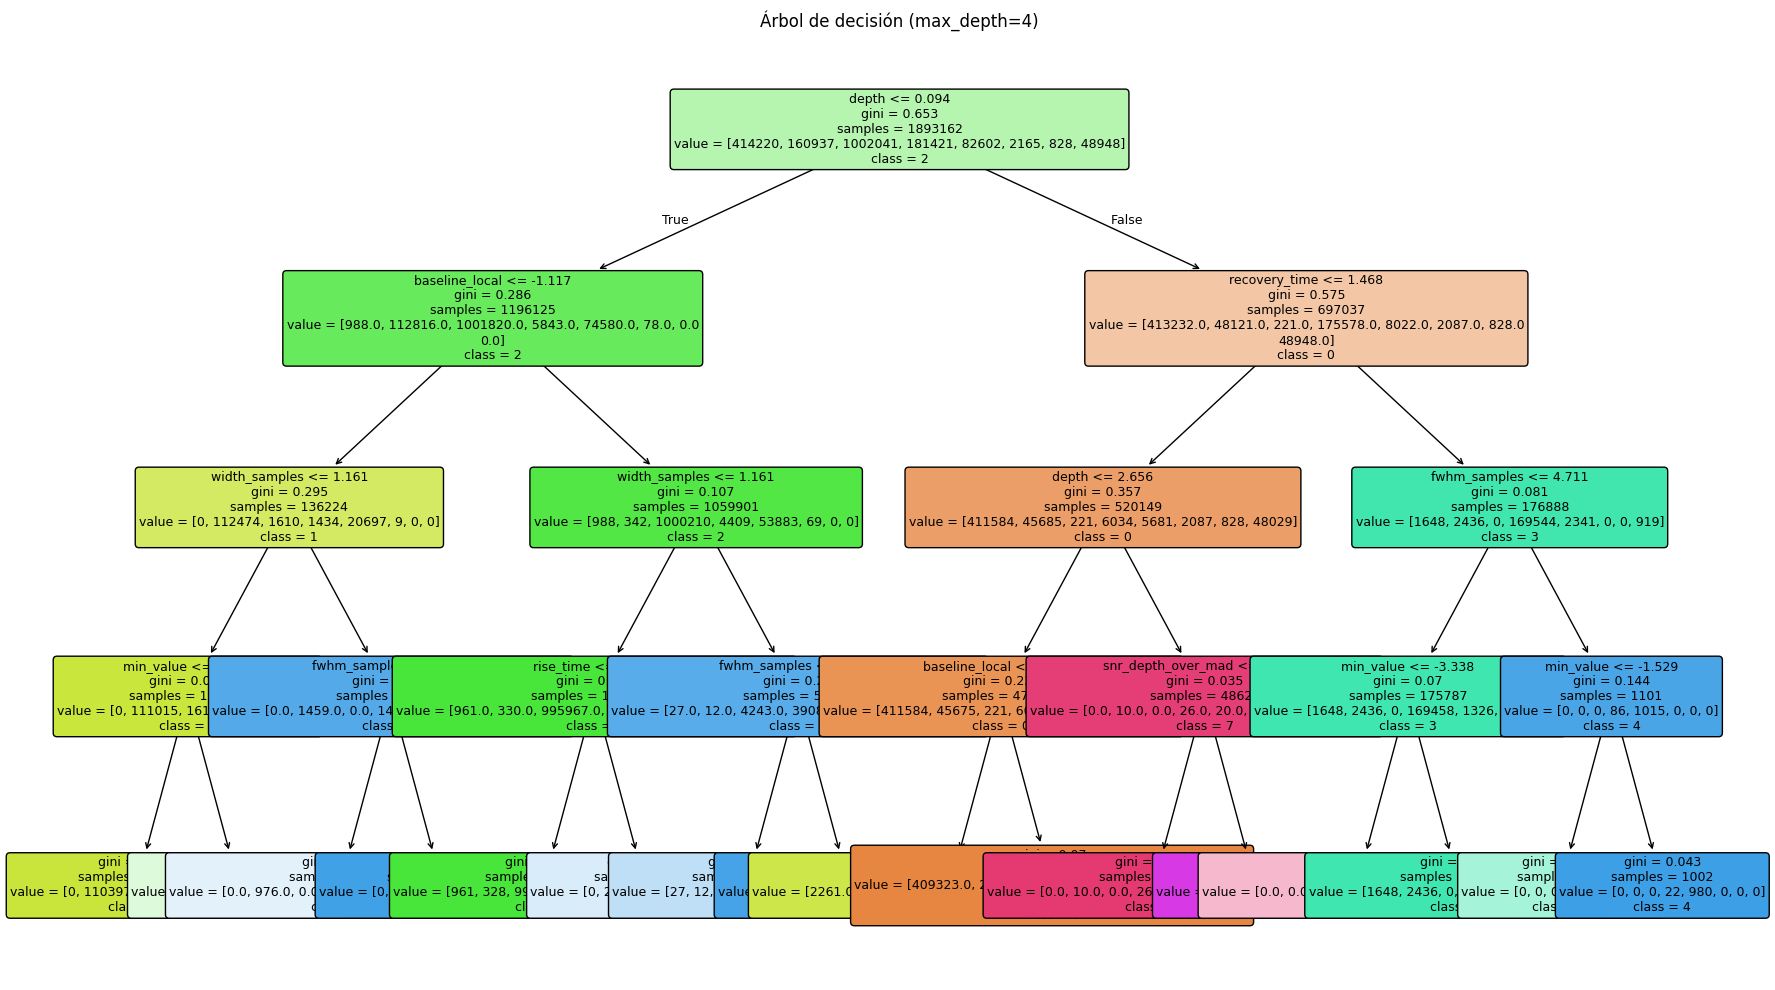

In [31]:
# Visualizar el árbol
plt.figure(figsize=(18,10))
plot_tree(
    dt,
    feature_names=feature_cols,
    class_names=[str(c) for c in np.unique(labels)],
    filled=True, rounded=True, fontsize=9
)
plt.title("Árbol de decisión (max_depth=4)")
plt.tight_layout()
plt.show()

## XGBoost

In [32]:
from xgboost import XGBClassifier

In [33]:
xgb = XGBClassifier(
    n_estimators=100,
    max_depth=5,
    max_leaves=3,
    learning_rate=0.005,
    eval_metric="mlogloss",
    early_stopping_rounds=5,       
    verbosity=2,         
    use_label_encoder=False
)

# Entrenar con early stopping
xgb.fit(
    X_tr_s, y_tr,
    eval_set=[(X_tr_s, y_tr), (X_val_s, y_val)],             
    verbose=True        
)

[20:43:30] INFO: /workspace/src/data/iterative_dmatrix.cc:53: Finished constructing the `IterativeDMatrix`: (1419871, 9, 12778839).
[20:43:30] INFO: /workspace/src/data/iterative_dmatrix.cc:53: Finished constructing the `IterativeDMatrix`: (473291, 9, 4259619).


/opt/conda/lib/python3.11/site-packages/xgboost/callback.py:386: UserWarning: [20:43:30] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  self.starting_round = model.num_boosted_rounds()


[0]	validation_0-mlogloss:2.06372	validation_1-mlogloss:2.06371
[1]	validation_0-mlogloss:2.04826	validation_1-mlogloss:2.04826
[2]	validation_0-mlogloss:2.03306	validation_1-mlogloss:2.03306
[3]	validation_0-mlogloss:2.01856	validation_1-mlogloss:2.01856
[4]	validation_0-mlogloss:2.00429	validation_1-mlogloss:2.00429
[5]	validation_0-mlogloss:1.99025	validation_1-mlogloss:1.99025
[6]	validation_0-mlogloss:1.97642	validation_1-mlogloss:1.97642
[7]	validation_0-mlogloss:1.96278	validation_1-mlogloss:1.96278
[8]	validation_0-mlogloss:1.94935	validation_1-mlogloss:1.94935
[9]	validation_0-mlogloss:1.93570	validation_1-mlogloss:1.93570
[10]	validation_0-mlogloss:1.92265	validation_1-mlogloss:1.92265
[11]	validation_0-mlogloss:1.90978	validation_1-mlogloss:1.90978
[12]	validation_0-mlogloss:1.89709	validation_1-mlogloss:1.89709
[13]	validation_0-mlogloss:1.88457	validation_1-mlogloss:1.88457
[14]	validation_0-mlogloss:1.87222	validation_1-mlogloss:1.87222
[15]	validation_0-mlogloss:1.86003	

,objective,'multi:softprob'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,5
,enable_categorical,False
,eval_metric,'mlogloss'


=== Métricas agregadas ===
Macro     -> P: 0.9682 | R: 0.9231 | F1: 0.9375
Weighted  -> P: 0.9687 | R: 0.9672 | F1: 0.9649

=== Classification report (por clase) ===
              precision    recall  f1-score   support

           0       0.98      0.97      0.98    103555
           1       0.95      0.98      0.96     40235
           2       0.99      1.00      0.99    250510
           3       0.86      0.96      0.90     45355
           4       0.98      0.55      0.71     20651
           5       1.00      0.94      0.97       541
           6       1.00      1.00      1.00       207
           7       0.99      0.98      0.99     12237

    accuracy                           0.97    473291
   macro avg       0.97      0.92      0.94    473291
weighted avg       0.97      0.97      0.96    473291



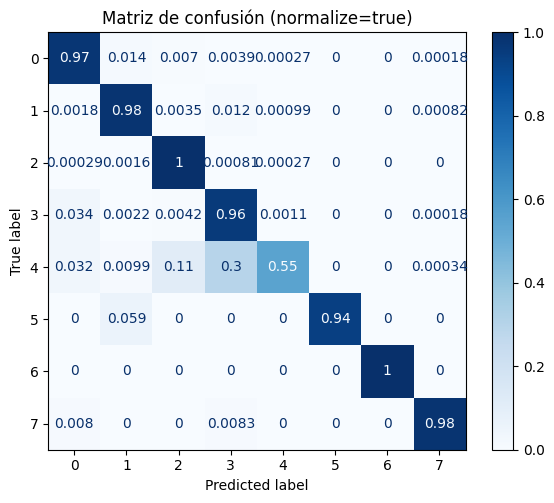


ROC-AUC multiclase:
  micro-average: 0.9982
  macro-average (ovr): 0.9978


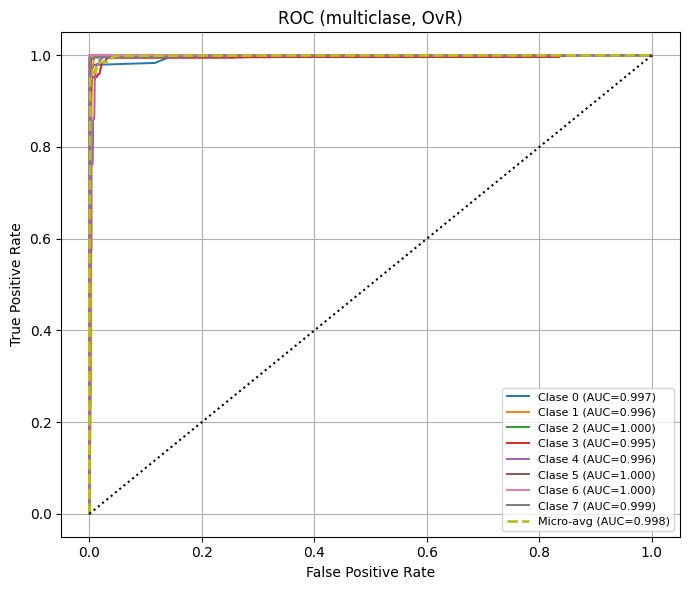


Average Precision multiclase:
  micro-average AP: 0.9906
  clase 0 AP: 0.9921
  clase 1 AP: 0.9344
  clase 2 AP: 0.9996
  clase 3 AP: 0.9745
  clase 4 AP: 0.9273
  clase 5 AP: 1.0000
  clase 6 AP: 1.0000
  clase 7 AP: 0.9946


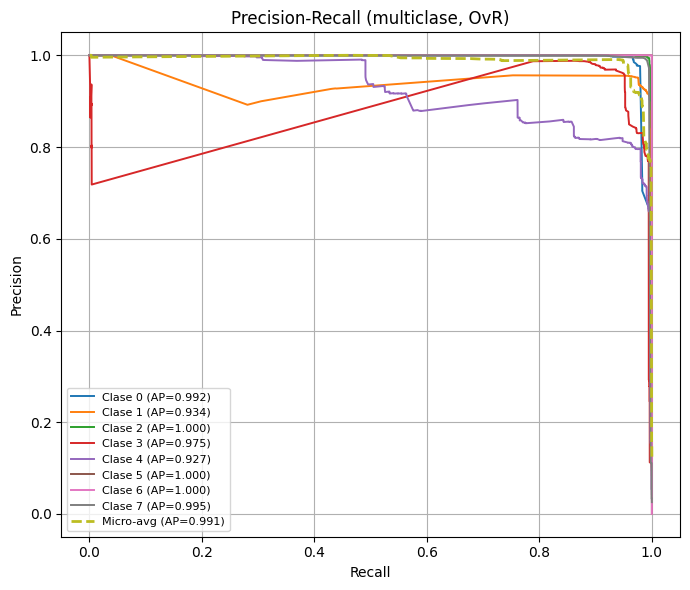

In [34]:
proba_xgb =  xgb.predict_proba(X_te_s)

_ = eval_predictions(y_true=y_te, y_pred=proba_xgb, plot_cm=True, plot_roc=True, plot_pr=True)

## MLP 

In [35]:
print("CUDA:", torch.cuda.is_available())
if torch.cuda.is_available():
    print(torch.cuda.get_device_name(0))

CUDA: True
NVIDIA A2


In [36]:
import torch, torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import torch.nn.functional as F

In [37]:
class MLP(nn.Module):
    def __init__(self, in_dim, out_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, 64), nn.ReLU(),
            nn.Linear(64, 32), nn.ReLU(),
            nn.Linear(32, out_dim)
        )
    def forward(self, x): return self.net(x)

In [38]:
def train_model(model, Xtr, ytr, Xte, yte, epochs=20, bs=64, lr=1e-3, patience=5):
    device = "cuda" if torch.cuda.is_available() else "cpu"
    model = model.to(device)
    Xtr, ytr = torch.tensor(Xtr, dtype=torch.float32), torch.tensor(ytr, dtype=torch.long)
    Xte, yte = torch.tensor(Xte, dtype=torch.float32), torch.tensor(yte, dtype=torch.long)
    train_loader = DataLoader(TensorDataset(Xtr, ytr), batch_size=bs, shuffle=True)
    
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.CrossEntropyLoss()

    best_val_loss = float("inf")
    patience_counter = 0
    history = {"train_loss": [], "val_loss": []}
    
    for epoch in range(1, epochs+1):
        # ---- Train ----
        model.train()
        train_loss = 0.0
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            opt.zero_grad()
            logits = model(xb)
            loss = loss_fn(logits, yb)
            loss.backward()
            opt.step()
            train_loss += loss.item() * len(xb)
        train_loss /= len(Xtr)

        # ---- Validation ----
        model.eval()
        with torch.no_grad():
            logits_val = model(Xte.to(device))
            val_loss = loss_fn(logits_val, yte.to(device)).item()

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)

        print(f"Epoch {epoch:03d} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

        # ---- Early stopping ----
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_counter = 0
            best_state = model.state_dict()
        else:
            patience_counter += 1
            print(f">>>patience_counter: {patience_counter}")
            if patience_counter >= patience:
                print(f"Early stopping en epoch {epoch}")
                break
                
    model.load_state_dict(best_state)

    plt.figure(figsize=(6,4))
    plt.plot(history["train_loss"], label="Train Loss")
    plt.plot(history["val_loss"], label="Val Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Curva de aprendizaje (MLP)")
    plt.legend()
    plt.grid(True)
    plt.show()
                
    #

    return model


In [39]:
mlp = MLP(X_tr_s.shape[1], len(np.unique(labels)))

In [ ]:
epochs=300
batch_size=500
lr=0.0001
patience=5

model = train_model(
    mlp, X_tr_s, y_tr, X_val_s, y_val, 
    epochs=epochs, 
    bs=batch_size, lr=lr,
    patience=patience
)

Epoch 001 | Train Loss: 0.3831 | Val Loss: 0.0544
Epoch 002 | Train Loss: 0.0392 | Val Loss: 0.0293


In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"

mlp_trained = model.to(device)

# Pasa Xte al mismo device
with torch.no_grad():
    Xte_t = torch.tensor(X_te_s, dtype=torch.float32).to(device)
    logits_test = mlp_trained(Xte_t)             # logits en device
    proba_mlp = F.softmax(logits_test, dim=1)    # aplicar softmax
    proba_mlp = proba_mlp.cpu().numpy()   

In [ ]:
_ = eval_predictions(y_true=y_te, y_pred=proba_mlp, plot_cm=True, plot_roc=True, plot_pr=True)

## ConvNet 1D

In [ ]:
class Conv1DNet(nn.Module):
    def __init__(self, in_dim, out_dim):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv1d(1,16,3,padding=1), nn.ReLU(),
            nn.Conv1d(16,32,3,padding=1), nn.ReLU(),
            nn.AdaptiveAvgPool1d(1)
        )
        self.fc = nn.Linear(32, out_dim)
    def forward(self, x):
        x = x.unsqueeze(1) # [batch,1,features]
        z = self.conv(x).squeeze(-1)
        return self.fc(z)

In [ ]:
X_tr_s.shape[1]

In [ ]:
conv = Conv1DNet(X_tr_s.shape[1], len(np.unique(labels)))

In [ ]:
epochs=300
batch_size=1024
lr=0.0005
patience=5

model_conv = train_model(
    conv, 
    X_tr_s, y_tr, X_val_s, y_val,
    epochs=epochs, 
    bs=batch_size, lr=lr,
    patience=patience
)

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"

cnn_trained = model_conv.to(device)

# Pasa Xte al mismo device
with torch.no_grad():
    Xte_t = torch.tensor(X_te_s, dtype=torch.float32).to(device)
    logits_test = cnn_trained(Xte_t)             # logits en device
    proba_cnn = F.softmax(logits_test, dim=1)    # aplicar softmax
    proba_cnn = proba_cnn.cpu().numpy()   

## Comparar Modelos

In [ ]:
res = compare_models(
    y_true=y_te,
    proba_dict={
        "XGBoost": proba_xgb,
        "MLP": proba_mlp,
        "DecisionTree": proba_dt,
        "Conv. Net": proba_cnn,
    },
    class_labels=np.unique(y_te),
    plot_roc=True,
    plot_pr=True
)

# Resumen en DataFrame:
res["summary"]
# Report por modelo:
print(res["reports"]["XGBoost"])


In [28]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, label_binarize
from sklearn.metrics import (
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    roc_curve,
    auc,
    precision_recall_curve,
    average_precision_score,
    accuracy_score
)

def eval_predictions(
    y_true,
    y_pred,
    threshold=0.5,
    labels=None,
    average='macro',
    multi_class='ovr',
    plot_cm=True,
    cm_normalize='true',   # 'true'|'pred'|'all'|None
    plot_roc=True,
    plot_pr=True,
):
    """
    Evalúa predicciones binarias o multiclase con métricas + gráficos:
    - PR/F1 (macro/weighted), classification_report
    - Matriz de confusión
    - ROC-AUC (binario y multiclase OvR: micro y macro)
    - Curvas ROC por clase + micro
    - Curvas Precision-Recall por clase + micro (AP)
    
    y_true: (n_samples,) etiquetas verdaderas (strings o ints)
    y_pred:
      * binario: prob. clase positiva (n_samples,)
      * multiclase: probs por clase (n_samples, n_classes)
      * etiquetas discretas (sin probas) también funciona, pero sin ROC/PR
    """
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    le = LabelEncoder()
    y_true_enc = le.fit_transform(y_true)
    
    if labels is None:
        class_names = le.classes_
    else:
        class_names = np.asarray(labels)
    
    # Fuerza a string para evitar TypeError con numpy.int64
    class_names_str = [str(c) for c in class_names]
    
    n_classes = len(np.unique(y_true_enc))

    results = {}

    # Detectar formato de y_pred
    proba_available = False
    multiclass = n_classes > 2

    if y_pred.ndim == 1:
        # Puede ser: etiquetas discretas o probas binario
        if set(np.unique(y_pred)).issubset(set(range(n_classes))) and y_pred.dtype.kind in "iu":
            # y_pred son etiquetas (no probabilidades)
            y_pred_labels = y_pred.astype(int)
        else:
            # Se asume probas binario
            proba_available = True
            multiclass = False
            y_pred_labels = (y_pred > threshold).astype(int)
    elif y_pred.ndim == 2:
        # Multiclase con probas
        proba_available = True
        multiclass = True
        if y_pred.shape[1] != n_classes:
            raise ValueError("y_pred de shape (n_samples, n_classes). #clases no coincide con y_true.")
        y_pred_labels = np.argmax(y_pred, axis=1)
    else:
        raise ValueError("Formato de y_pred no soportado.")

    # ---- Métricas de clasificación ----
    prec_macro, rec_macro, f1_macro, _ = precision_recall_fscore_support(
        y_true_enc, y_pred_labels, average='macro', zero_division=0
    )
    prec_weight, rec_weight, f1_weight, _ = precision_recall_fscore_support(
        y_true_enc, y_pred_labels, average='weighted', zero_division=0
    )

    print("=== Métricas agregadas ===")
    print(f"Macro     -> P: {prec_macro:.4f} | R: {rec_macro:.4f} | F1: {f1_macro:.4f}")
    print(f"Weighted  -> P: {prec_weight:.4f} | R: {rec_weight:.4f} | F1: {f1_weight:.4f}")

    cr = classification_report(y_true_enc, y_pred_labels, target_names=class_names_str, zero_division=0)
    print("\n=== Classification report (por clase) ===")
    print(cr)

    results.update({
        "precision_macro": prec_macro,
        "recall_macro": rec_macro,
        "f1_macro": f1_macro,
        "precision_weighted": prec_weight,
        "recall_weighted": rec_weight,
        "f1_weighted": f1_weight,
        "classification_report_str": cr,
        "y_pred_labels": y_pred_labels
    })

    # ---- Matriz de confusión ----
    if plot_cm:
        cm = confusion_matrix(y_true_enc, y_pred_labels, normalize=cm_normalize)
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names_str)
        fig, ax = plt.subplots(figsize=(6,5))
        disp.plot(ax=ax, cmap="Blues", colorbar=True)
        ax.set_title("Matriz de confusión" + (f" (normalize={cm_normalize})" if cm_normalize else ""))
        plt.tight_layout(); plt.show()
        results["confusion_matrix"] = cm

    # Si no hay probabilidades no podemos trazar ROC/PR
    if not proba_available:
        return results

    # ---- ROC ----
    if not multiclass:
        fpr, tpr, thr = roc_curve(y_true_enc, y_pred, pos_label=1)
        roc_auc = auc(fpr, tpr)
        print(f"\nROC-AUC (binario): {roc_auc:.4f}")
        if plot_roc:
            plt.figure(figsize=(6,5))
            plt.plot(fpr, tpr, lw=2, label=f'ROC (AUC={roc_auc:.3f})')
            plt.plot([0,1],[0,1], linestyle='--')
            plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
            plt.title('ROC (binario)')
            plt.legend(); plt.grid(True); plt.tight_layout(); plt.show()
        results.update({"roc_auc": roc_auc, "roc_curve": {"fpr": fpr, "tpr": tpr, "thresholds": thr}})
    else:
        y_true_bin = label_binarize(y_true_enc, classes=np.arange(n_classes))
        fpr_d, tpr_d, auc_d = {}, {}, {}
        for c in range(n_classes):
            fpr_d[c], tpr_d[c], _ = roc_curve(y_true_bin[:,c], y_pred[:,c])
            auc_d[c] = auc(fpr_d[c], tpr_d[c])

        # micro y macro
        fpr_micro, tpr_micro, _ = roc_curve(y_true_bin.ravel(), y_pred.ravel())
        auc_micro = auc(fpr_micro, tpr_micro)
        auc_macro = roc_auc_score(y_true_enc, y_pred, multi_class=multi_class, average="macro")
        print("\nROC-AUC multiclase:")
        print(f"  micro-average: {auc_micro:.4f}")
        print(f"  macro-average ({multi_class}): {auc_macro:.4f}")

        if plot_roc:
            plt.figure(figsize=(7,6))
            for c in range(n_classes):
                plt.plot(fpr_d[c], tpr_d[c], lw=1.4, label=f"Clase {class_names_str[c]} (AUC={auc_d[c]:.3f})")
            plt.plot(fpr_micro, tpr_micro, lw=2, linestyle='--', label=f"Micro-avg (AUC={auc_micro:.3f})")
            plt.plot([0,1],[0,1], linestyle=':', color='black')
            plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
            plt.title('ROC (multiclase, OvR)')
            plt.legend(loc='lower right', fontsize=8)
            plt.grid(True); plt.tight_layout(); plt.show()

        results.update({
            "roc_auc_micro": auc_micro,
            "roc_auc_macro": auc_macro,
            "roc_auc_per_class": auc_d
        })

    # ---- Precision-Recall ----
    if not multiclass:
        prec, rec, thr = precision_recall_curve(y_true_enc, y_pred, pos_label=1)
        ap = average_precision_score(y_true_enc, y_pred)
        print(f"\nAverage Precision (binario): {ap:.4f}")
        if plot_pr:
            plt.figure(figsize=(6,5))
            plt.plot(rec, prec, lw=2, label=f'PR (AP={ap:.3f})')
            plt.xlabel('Recall'); plt.ylabel('Precision')
            plt.title('Precision-Recall (binario)')
            plt.legend(); plt.grid(True); plt.tight_layout(); plt.show()
        results.update({"ap": ap, "pr_curve": {"precision": prec, "recall": rec, "thresholds": thr}})
    else:
        y_true_bin = label_binarize(y_true_enc, classes=np.arange(n_classes))
        pr_d, rc_d, ap_d = {}, {}, {}
        for c in range(n_classes):
            prec_c, rec_c, _ = precision_recall_curve(y_true_bin[:,c], y_pred[:,c])
            ap_c = average_precision_score(y_true_bin[:,c], y_pred[:,c])
            pr_d[c], rc_d[c], ap_d[c] = prec_c, rec_c, ap_c

        # Micro-average PR
        prec_micro, rec_micro, _ = precision_recall_curve(y_true_bin.ravel(), y_pred.ravel())
        ap_micro = average_precision_score(y_true_bin, y_pred, average="micro")

        print("\nAverage Precision multiclase:")
        print(f"  micro-average AP: {ap_micro:.4f}")
        for c in range(n_classes):
            print(f"  clase {class_names_str[c]} AP: {ap_d[c]:.4f}")

        if plot_pr:
            plt.figure(figsize=(7,6))
            for c in range(n_classes):
                plt.plot(rc_d[c], pr_d[c], lw=1.4, label=f"Clase {class_names_str[c]} (AP={ap_d[c]:.3f})")
            plt.plot(rec_micro, prec_micro, lw=2, linestyle='--', label=f"Micro-avg (AP={ap_micro:.3f})")
            plt.xlabel('Recall'); plt.ylabel('Precision')
            plt.title('Precision-Recall (multiclase, OvR)')
            plt.legend(loc='lower left', fontsize=8)
            plt.grid(True); plt.tight_layout(); plt.show()

        results.update({
            "ap_micro": ap_micro,
            "ap_per_class": ap_d
        })

    return results


In [29]:
def compare_models(
    y_true,
    proba_dict=None,         # dict: {"Modelo": y_pred_proba}  -> (N,) binario o (N,C) multiclase
    labels_dict=None,        # dict: {"Modelo": y_pred_labels} -> (N,)
    class_labels=None,       # lista opcional de nombres de clases para mostrar
    average='macro',
    multi_class='ovr',
    plot_roc=True,
    plot_pr=True,
    show_table=True
):
    """
    Compara múltiples modelos con métricas agregadas y curvas ROC/PR superpuestas.
    - Soporta binario y multiclase.
    - Si hay probabilidades, se usan para ROC/PR; si no, se evalúan solo métricas de clasificación.

    Parámetros
    ----------
    y_true : array (N,)
    proba_dict : dict[str, np.ndarray] -> probabilidades por modelo
    labels_dict : dict[str, np.ndarray] -> etiquetas discretas por modelo
    class_labels : lista de nombres de clases (para impresión)
    average : 'macro'/'weighted' (para PR/F1 agregadas)
    multi_class : 'ovr' o 'ovo' (para ROC-AUC multiclase)
    """
    if proba_dict is None and labels_dict is None:
        raise ValueError("Proporciona al menos proba_dict o labels_dict.")

    y_true = np.asarray(y_true)
    le = LabelEncoder()
    y_true_enc = le.fit_transform(y_true)
    n_classes = len(np.unique(y_true_enc))
    is_multiclass = n_classes > 2

    # nombres de clase seguros (str)
    if class_labels is None:
        class_names = [str(c) for c in le.classes_]
    else:
        class_names = [str(c) for c in class_labels]

    # Unificar entradas en un diccionario de resultados por modelo
    models = set()
    if proba_dict: models |= set(proba_dict.keys())
    if labels_dict: models |= set(labels_dict.keys())
    models = sorted(models)

    rows = []          # para la tabla resumen
    reports = {}       # classification_report por modelo
    curves = {"roc": {}, "pr": {}}  # curvas por modelo

    # ------------------ BUCLE POR MODELO ------------------
    for name in models:
        # Probabilidades y etiquetas disponibles
        proba = proba_dict.get(name, None) if proba_dict else None
        yhat  = labels_dict.get(name, None) if labels_dict else None

        # Si hay proba, derivamos etiquetas (argmax / threshold)
        if proba is not None:
            proba = np.asarray(proba)
            if proba.ndim == 1:     # binario: prob. de clase positiva
                if is_multiclass:
                    raise ValueError(f"{name}: proba es 1D pero el problema es multiclase.")
                yhat_from_proba = (proba > 0.5).astype(int)
            elif proba.ndim == 2:
                if proba.shape[1] != n_classes:
                    raise ValueError(f"{name}: columnas de proba ({proba.shape[1]}) != n_classes ({n_classes}).")
                yhat_from_proba = np.argmax(proba, axis=1)
            else:
                raise ValueError(f"{name}: formato de probabilidades no soportado.")
            if yhat is None:
                yhat = yhat_from_proba

        if yhat is None:
            raise ValueError(f"{name}: se requieren etiquetas o probabilidades para evaluar.")

        yhat = np.asarray(yhat)

        # --- Métricas clasificatorias
        acc = accuracy_score(y_true_enc, yhat)
        p_macro, r_macro, f1_macro, _ = precision_recall_fscore_support(y_true_enc, yhat, average='macro', zero_division=0)
        p_weight, r_weight, f1_weight, _ = precision_recall_fscore_support(y_true_enc, yhat, average='weighted', zero_division=0)
        report_str = classification_report(y_true_enc, yhat, target_names=class_names, zero_division=0)

        rows.append({
            "modelo": name,
            "accuracy": acc,
            "precision_macro": p_macro, "recall_macro": r_macro, "f1_macro": f1_macro,
            "precision_weighted": p_weight, "recall_weighted": r_weight, "f1_weighted": f1_weight
        })
        reports[name] = report_str

        # --- ROC / PR si hay probabilidades
        if proba is not None:
            if not is_multiclass:
                # ROC
                fpr, tpr, _ = roc_curve(y_true_enc, proba, pos_label=1)
                auc_roc = auc(fpr, tpr)
                curves["roc"][name] = {"fpr": fpr, "tpr": tpr, "auc": auc_roc}
                # PR
                prec, rec, _ = precision_recall_curve(y_true_enc, proba, pos_label=1)
                ap = average_precision_score(y_true_enc, proba)
                curves["pr"][name] = {"precision": prec, "recall": rec, "ap": ap}
            else:
                # multiclase: micro/macro
                y_true_bin = label_binarize(y_true_enc, classes=np.arange(n_classes))
                # ROC micro
                fpr_micro, tpr_micro, _ = roc_curve(y_true_bin.ravel(), proba.ravel())
                auc_micro = auc(fpr_micro, tpr_micro)
                # ROC macro (usamos roc_auc_score)
                auc_macro = roc_auc_score(y_true_enc, proba, multi_class=multi_class, average="macro")
                curves["roc"][name] = {
                    "fpr_micro": fpr_micro, "tpr_micro": tpr_micro,
                    "auc_micro": auc_micro, "auc_macro": auc_macro
                }
                # PR micro
                prec_micro, rec_micro, _ = precision_recall_curve(y_true_bin.ravel(), proba.ravel())
                ap_micro = average_precision_score(y_true_bin, proba, average="micro")
                curves["pr"][name] = {
                    "precision_micro": prec_micro, "recall_micro": rec_micro,
                    "ap_micro": ap_micro
                }

    # ------------------ TABLA RESUMEN ------------------
    summary = pd.DataFrame(rows).sort_values(by=["f1_macro", "accuracy"], ascending=False).reset_index(drop=True)
    if show_table:
        print("\n=== Resumen de modelos ===")
        display(summary)  # en notebook; si no, usa print(summary)

    # ------------------ PLOTS COMPARATIVOS ------------------
    # ROC
    if plot_roc and any(curves["roc"].values()):
        plt.figure(figsize=(7,6))
        for name, d in curves["roc"].items():
            if not is_multiclass:
                plt.plot(d["fpr"], d["tpr"], lw=2, label=f"{name} (AUC={d['auc']:.3f})")
            else:
                plt.plot(d["fpr_micro"], d["tpr_micro"], lw=2, label=f"{name} (AUC micro={d['auc_micro']:.3f}, macro={d['auc_macro']:.3f})")
        plt.plot([0,1],[0,1], linestyle='--', color='gray')
        plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
        plt.title("ROC comparativo" + (" (multiclase: micro)" if is_multiclass else " (binario)"))
        plt.legend(loc="lower right"); plt.grid(True); plt.tight_layout(); plt.show()

    # PR
    if plot_pr and any(curves["pr"].values()):
        plt.figure(figsize=(7,6))
        for name, d in curves["pr"].items():
            if not is_multiclass:
                plt.plot(d["recall"], d["precision"], lw=2, label=f"{name} (AP={d['ap']:.3f})")
            else:
                plt.plot(d["recall_micro"], d["precision_micro"], lw=2, label=f"{name} (AP micro={d['ap_micro']:.3f})")
        plt.xlabel("Recall"); plt.ylabel("Precision")
        plt.title("Precision-Recall comparativo" + (" (multiclase: micro)" if is_multiclass else " (binario)"))
        plt.legend(loc="lower left"); plt.grid(True); plt.tight_layout(); plt.show()

    return {
        "summary": summary,
        "reports": reports,
        "curves": curves,
        "is_multiclass": is_multiclass,
        "class_names": class_names
    }
